# Example: Data-Driven Minimum-Variance Portfolios, the Efficient Frontier, and the Capital Allocation Line

In L5a, we estimated how asset growth rates vary together and sampled candidate portfolio allocations. We now ask how to choose those allocations. For a selected set of firms, which portfolio has the smallest estimated growth-rate variance? How do the weights change when we require a higher expected growth rate? We use the mean-variance framework from the L5b lecture to answer these questions.

> __Learning Objectives:__
>
> By the end of this example, you should be able to:
>
> * __Estimate inputs and compute minimum-variance portfolios:__ Calculate the sample-mean growth-rate vector and covariance matrix for a selected set of firms. Compute the global minimum-variance weights in closed form and with a long-only solver, and explain how forbidding short positions changes the allocation and risk.
> * __Construct the efficient frontier and capital allocation line:__ Vary the required expected growth rate to trace the long-only efficient frontier. Add a risk-free asset, approximate the tangent portfolio from the frontier sweep, and interpret the capital allocation line and the one-day and annualized Sharpe ratios.
> * __Evaluate portfolios out of sample:__ Compare the buy-and-hold wealth, realized growth rate, and growth-rate standard deviation of the optimized portfolios, an equal-weight portfolio, and an index fund. Explain what a one-year comparison can and cannot tell us about their performance.

In this example, we use 2014 to 2024 data to estimate the portfolio inputs and choose the weights. We reserve 2025 prices for the final comparison, so those prices do not influence the optimization. This lets us examine whether the growth and risk characteristics estimated from the training data carried over to the following year.

Let's get started!

___


## Setup, Data, and Prerequisites
First, we load the local [`Include.jl`](Include.jl) setup file and its required packages.

> __Include:__ The [`include(...)` command](https://docs.julialang.org/en/v1/base/base/#include) evaluates [`Include.jl`](Include.jl) in the notebook's global scope. The setup file activates the course project, defines local paths, loads the required packages, and includes local helper code.

Let's set up our code environment:

In [1]:
# Load the course environment, market data, and portfolio solver -
include(joinpath(@__DIR__, "Include.jl")); # resolve setup relative to this notebook

  Activating 

project at `~/Desktop/julia_work/CHEME-5660-CourseRepository-Fall-2026`


See the [Julia documentation](https://docs.julialang.org/en/v1/) and the [CHEME 5660 Quantitative Finance Package documentation](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/) for the functions and types used here.

### Data
The training dataset contains daily open-high-low-close (OHLC) records for firms in the [S&P 500](https://en.wikipedia.org/wiki/S%26P_500) from January 3, 2014 through December 31, 2024, along with records for several exchange-traded funds and volatility products. We use this dataset to estimate the mean growth rates and covariance matrix. The testing dataset covers January 2 through December 31, 2025 and is reserved for the final portfolio comparison.

We use each day's volume-weighted average price (VWAP) as our share-price observation. It averages transaction prices using the number of shares traded as weights. These observations are stored in the `volume_weighted_average_price` column, which we use for both growth-rate calculations and the later buy-and-hold wealth comparison.

Let's load the training data using [the `MyTrainingMarketDataSet()` function](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/data/#VLQuantitativeFinancePackage.MyTrainingMarketDataSet). Not every ticker has a complete history, so we retain those with the same number of records as `AAPL`, which has a full history over this period. We store the retained price tables in `dataset::Dict{String,DataFrame}`, keyed by ticker symbol:

In [2]:
dataset = let

    # Load training prices and allocate a ticker-to-price-table dictionary -
    original_dataset = MyTrainingMarketDataSet() |> x-> x["dataset"]; # training data, 2014 to 2024
    maximum_number_trading_days = original_dataset["AAPL"] |> nrow; # AAPL has the maximum number of trading days
    dataset = Dict{String, DataFrame}(); # retain complete training histories

    # Filter by price-row count; Task 1 separately checks alignment of the selected dates -
    for (ticker, data) ∈ original_dataset
        if (nrow(data) == maximum_number_trading_days)
            dataset[ticker] = data;
        end
    end
    dataset; # return the filtered training data from this local block
end;

Next, we load the testing data using [the `MyTestingMarketDataSet()` function](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/data/#VLQuantitativeFinancePackage.MyTestingMarketDataSet). We apply the same record-count check within the 2025 dataset and store the retained price tables in `dataset_2025::Dict{String,DataFrame}`. Equal record counts alone do not establish date alignment; in Task 1, we also check that the selected firms share the same trading dates within each dataset.

In [3]:
dataset_2025 = let

    # Load testing prices and allocate a ticker-to-price-table dictionary -
    original_dataset = MyTestingMarketDataSet() |> x-> x["dataset"]; # testing data, calendar year 2025
    maximum_number_trading_days = original_dataset["AAPL"] |> nrow;
    dataset = Dict{String, DataFrame}(); # retain complete testing histories

    # Filter by price-row count; Task 1 separately checks alignment of the selected dates -
    for (ticker, data) ∈ original_dataset
        if (nrow(data) == maximum_number_trading_days)
            dataset[ticker] = data;
        end
    end
    dataset; # return the filtered testing data from this local block
end;

We also load the L4b parameter table into `parameters_df::DataFrame` to check the estimates we compute in Task 1. Its `volatility` column contains the estimate $\hat{\sigma}=\sigma_g\sqrt{\Delta t}$. The column labeled `drift` contains L4b's regression estimate of the mean growth rate, rather than the arithmetic drift of the GBM model. We retain the existing column name when reading the file:

In [4]:
# Load earlier estimates for comparison; drift is the regression mean growth, not GBM price drift -
parameters_df = CSV.read(joinpath(_PATH_TO_DATA, "SAGBM-Parameters-Fall-2025.csv"), DataFrame); # L4b parameter table

### Constants
Finally, we set the daily time step, initial wealth, and number of target growth rates in the frontier sweep. The comments below give their meaning and units.

In [5]:
# Set the common time/wealth units and the resolution of the numerical target sweep -
Δt = (1.0/252.0); # time step (1 trading day, in years)
g_f = 0.041; # risk-free growth rate (1/yr); approximate continuous rate from 4.16% 1-year Treasury yield (2024-12-31)
W₀ = 1000.0; # initial wealth (units: USD)
number_of_points = 101; # number of target growth rates in the frontier sweep

___

## Task 1: Estimate Inputs and Compute Minimum-Variance Portfolios
In this task, we estimate the mean growth rates and covariance matrix for a selected set of firms, then compute the global minimum-variance portfolio with and without short positions. The mean-growth vector describes the reward associated with an allocation, while the covariance matrix determines the variance we minimize.

### Choose the firms
Before computing the inputs, we must decide which firms the portfolio may hold. We use the same estimation procedure as in the L5a covariance example, applied to our selected firms.

> __Ticker picker question:__ Which firms should we include? This choice affects the portfolios we can construct because the optimizer can assign weight only to the firms it receives. Our starting list includes technology firms, semiconductor firms, banks, automakers, and a health-care firm.

Specify the ticker symbols in `my_list_of_tickers::Array{String,1}`. You can change this list, but choose firms with complete histories in both datasets and fix the selection before examining their 2025 performance. We check the selected firms' trading dates before computing the inputs.

In [6]:
# Fix the asset universe before looking at 2025 performance -
# This order controls every mean, covariance row/column, weight, and testing-price column.
my_list_of_tickers = ["AAPL", "MSFT", "INTC", "MU", "AMD", "NVDA", "GS", "BAC", "WFC", "C", "F", "GM", "JNJ"]; # M = 13 firms

### Estimate the portfolio inputs
First, we verify that the selected firms share the same trading dates within each dataset. This matters because [the `log_growth_matrix(...)` function](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/equity/#VLQuantitativeFinancePackage.log_growth_matrix) pairs price records by row position.

Following L4b, we compute the one-step growth rate from two successive prices. For multiple firms, we use the notation from L5a: $i$ and $j$ index firms, while $k$ indexes observation intervals. If $S_{k-1}^{(i)}$ and $S_k^{(i)}$ are successive prices of firm $i$, its growth rate is given by:
$$
g_k^{(i)}=\frac{1}{\Delta t}\ln\!\left(\frac{S_k^{(i)}}{S_{k-1}^{(i)}}\right),
\qquad k=1,\ldots,N,\quad i=1,\ldots,M.
$$
Thus, $N+1$ price records give $N$ growth observations. We collect these observations in $\mathbf{G}\in\mathbb{R}^{N\times M}$, with $g_k^{(i)}$ in row $k$, column $i$. The columns follow the order of `my_list_of_tickers`, and the entries have units of inverse years.

As in L5a, we compute each column's sample mean and subtract it to form the centered matrix $\tilde{\mathbf{G}}$. Column $i$ then contains the deviations $g_k^{(i)}-g_i^{\prime}$. For $N\geq2$, the sample means and covariance matrix are given by:
$$
g_i^{\prime}=\frac{1}{N}\sum_{k=1}^{N}g_k^{(i)},
\qquad
\hat{\mathbf{\Sigma}}_g=\frac{1}{N-1}\tilde{\mathbf{G}}^{\top}\tilde{\mathbf{G}}.
$$
The vector $\mathbf{g}^{\prime}$ estimates the mean-growth vector $\boldsymbol{\mu}_g$ and has units of inverse years. The covariance matrix has units of inverse years squared. We compute these estimates using [the `mean(...)` function](https://docs.julialang.org/en/v1/stdlib/Statistics/#Statistics.mean) and [the `cov(...)` function](https://docs.julialang.org/en/v1/stdlib/Statistics/#Statistics.cov), and store them in `ĝ` and `Σ̂_g`, respectively.

For the L4b volatility check and the correlation plot, we also compute the covariance rate and correlation matrix:
$$
\hat{\mathbf{C}}=\Delta t\,\hat{\mathbf{\Sigma}}_g,
\qquad
\hat\rho_{ij}=\frac{\hat\Sigma_{g,ij}}{\sqrt{\hat\Sigma_{g,ii}\hat\Sigma_{g,jj}}}.
$$
We store these in `Ĉ` and `ρ̂`. The covariance rate has units of inverse years, while the correlations are dimensionless.

Finally, [the `isposdef(...)` function](https://docs.julialang.org/en/v1/stdlib/LinearAlgebra/#LinearAlgebra.isposdef) checks that the estimated covariance is positive definite, as required by the closed-form portfolio weights. Having more observations than firms does not guarantee this condition: the growth series must also avoid exact linear dependence after centering. Let's compute and check the estimates:

In [7]:
ĝ, Σ̂_g, Ĉ, ρ̂ = let

    # check: the chosen firms share the same trading dates (rows are aligned by position) -
    for ticker ∈ my_list_of_tickers
        @assert dataset[ticker].timestamp == dataset["AAPL"].timestamp
        @assert dataset_2025[ticker].timestamp == dataset_2025["AAPL"].timestamp
    end

    # build the growth-rate data matrix (N observation intervals × M firms) -
    G = log_growth_matrix(dataset, my_list_of_tickers, Δt = Δt); # growth rates g (units: 1/years)

    # estimate the inputs -
    # dims=1 averages over growth intervals; vec converts the resulting row to an M-entry vector.
    ĝ = mean(G, dims=1) |> vec; # sample-mean vector g′; estimates μ_g (units: 1/years)
    Σ̂_g = cov(G, dims=1); # growth-rate covariance Cov(g) (units: 1/years²)
    Ĉ = Δt*Σ̂_g; # GBM covariance rate (units: 1/years)
    σ_g = sqrt.(diag(Σ̂_g)); # growth-rate standard deviations (units: 1/years)
    ρ̂ = Σ̂_g ./ (σ_g*σ_g'); # outer product supplies σ_i σ_j for entrywise normalization
    @assert isposdef(Σ̂_g) # verified for these aligned series; the closed forms below require it

    (ĝ, Σ̂_g, Ĉ, ρ̂); # return inputs in the order of the assignment outside the block
end;

### Check the estimates against L4b
Let's compare our estimates with the L4b parameter table, matching each firm by ticker symbol. First, the diagonal of the covariance rate gives the volatility estimate:
$$
\hat{\sigma}_i=\sqrt{\hat C_{ii}}
=\sqrt{\Delta t}\sqrt{\hat\Sigma_{g,ii}}
=\sigma_{g,i}\sqrt{\Delta t}.
$$
Here, $\sigma_{g,i}$ is the sample standard deviation of firm $i$'s one-step growth rates. This is the same calculation used in L4b, with the same prices and time step, so the volatility estimates should agree to numerical precision. The assertion below checks that agreement.

We also compare the sample-mean growth rate $g_i^{\prime}$ with L4b's regression estimate of $\mu_{g,i}$. The first averages the observed growth rates; the second fits a line to the log prices. Both estimate the mean growth rate, but they need not give the same value on a finite dataset. Let's display the comparison using [the `pretty_table(...)` function](https://ronisbr.github.io/PrettyTables.jl/stable/lib/library/#PrettyTables.pretty_table):

In [8]:
let
    # Build a comparison table without changing the full-precision optimization inputs -
    df = DataFrame(ticker = String[], g_mean = Float64[], σ_g = Float64[], σ̂ = Float64[], L4b_drift = Float64[]);
    
    # i is the selected-universe position; j is independently located in the parameter table.
    for (i, ticker) ∈ enumerate(my_list_of_tickers)
        j = findfirst(==(ticker), parameters_df.ticker); # look the firm up by name in the L4b table
        σ̂ᵢ = sqrt(Ĉ[i,i]); # volatility estimate from the covariance rate (units: 1/years^(1/2))
        @assert isapprox(σ̂ᵢ, parameters_df[j, :volatility], rtol = 1e-10) # volatility estimates should agree to numerical precision
        # Compare mean estimators, but assert agreement only for the shared volatility calculation.
        push!(df, (ticker = ticker, g_mean = round(ĝ[i], digits=4), σ_g = round(sqrt(Σ̂_g[i,i]), digits=3), 
            σ̂ = round(σ̂ᵢ, digits=4), L4b_drift = round(parameters_df[j, :drift], digits=4)));
    end

    # build a table -
    pretty_table(df, backend = :text, table_format = TextTableFormat(borders = text_table_borders__compact))
end

 -------- --------- --------- --------- -----------
  ticker    g_mean       σ_g         σ̂   L4b_drift 
  String   Float64   Float64   Float64     Float64 
 -------- --------- --------- --------- -----------
    AAPL    0.2328     3.723    0.2345      0.2427
    MSFT    0.2222     3.421    0.2155      0.2471
    INTC   -0.0228     4.672    0.2943      0.0118
      MU    0.1266     6.454    0.4066      0.1591
     AMD     0.312     7.529    0.4743      0.4397
    NVDA    0.5324     6.169    0.3886      0.5033
      GS    0.1064     3.898    0.2456      0.0911
     BAC    0.0897     4.266    0.2687      0.0931
     WFC      0.04     4.211    0.2653     -0.0139
       C    0.0258     4.518    0.2846      0.0054
       F   -0.0407     5.101    0.3213     -0.0184
      GM    0.0268     5.102    0.3214      0.0245
     JNJ     0.041     2.441    0.1537      0.0538
 -------- --------- --------- --------- -----------


Compare the sign and magnitude of `g_mean` and `L4b_drift` for each firm. Both columns have units of inverse years, and their differences show how the estimated mean growth depends on the estimation method. The frontier and tangent-portfolio calculations below use the sample means in `g_mean`.

The `σ_g` column gives the growth-rate standard deviation in inverse years. The `σ̂` column gives the corresponding GBM volatility in inverse square-root years. Their different numerical scales come from the time-step conversion above.

### Interpret the correlation matrix
The magnitude of a covariance depends on both firms' variability. Correlation divides out those scales so we can compare the strength of linear relationships across firms. Let's display `ρ̂` using [the `heatmap(...)` function](https://docs.juliaplots.org/stable/api/#Plots.heatmap-Tuple), with blue for positive correlation, red for negative correlation, and white for values near zero:

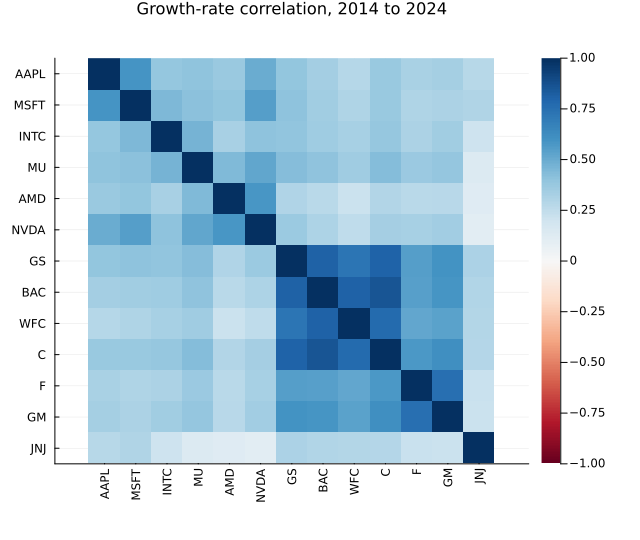

In [9]:
let
    # Display dimensionless pair correlations with ticker labels on both axes -
    M = length(my_list_of_tickers);
    # Fix colors to [-1,1]; yflip places matrix row 1 at the top.
    heatmap(ρ̂, xticks = (1:M, my_list_of_tickers), yticks = (1:M, my_list_of_tickers), xrotation = 90,
        color = :RdBu, clims = (-1, 1), colorbar_ticks = (-1:0.5:1), aspect_ratio = :equal, yflip = true,
        title = "Growth-rate correlation, 2014 to 2024", titlefontsize = 11, right_margin = 10Plots.mm, size = (640, 540))
end

**Each off-diagonal cell compares a pair of firms.** Strong blue regions identify firms whose growth rates tend to be above or below their own means together. Use the ticker labels to see whether firms in the same industry form such groups, and look for pairs with weaker linear relationships. The diagonal is one because each firm is perfectly correlated with itself.

For fixed positive weights and individual variances, a lower correlation reduces a pair's contribution to portfolio variance through its covariance. The covariance matrix combines these relationships with each firm's variability. We now use it to find the allocation with the smallest estimated growth-rate variance.

### Compute the global minimum-variance portfolio
We now use the estimated covariance matrix to find the fully invested portfolio with the smallest growth-rate variance. We first allow short positions, then impose long-only bounds to see how restricting the available allocations changes the result.

The global minimum-variance (GMV) portfolio minimizes $\mathbf{w}^{\top}\hat{\mathbf{\Sigma}}_g\mathbf{w}$ with no required growth target. When the only constraint is the budget $\mathbf{1}^{\top}\mathbf{w}=1$, the lecture gives the weights and minimum variance as:
$$
\mathbf{w}_{\mathrm{GMV}}
=\frac{\hat{\mathbf{\Sigma}}_g^{-1}\mathbf{1}}
{\mathbf{1}^{\top}\hat{\mathbf{\Sigma}}_g^{-1}\mathbf{1}},
\qquad
\sigma_{\mathrm{GMV}}^2
=\frac{1}{\mathbf{1}^{\top}\hat{\mathbf{\Sigma}}_g^{-1}\mathbf{1}}.
$$
Here, $\mathbf{1}\in\mathbb{R}^M$ is a vector of ones. The denominator normalizes the weights so they sum to one. A negative weight represents a short position, which this formulation permits.

We compute the weights in two steps. First, let $\mathbf{x}=\hat{\mathbf{\Sigma}}_g^{-1}\mathbf{1}$ denote the vector in the numerator. Its entries are the weights before normalization. We obtain this vector by solving the linear system:
$$
\hat{\mathbf{\Sigma}}_g\mathbf{x}=\mathbf{1}.
$$
In Julia, `x = Σ̂_g \ one_vector` performs this calculation using [the backslash operator](https://docs.julialang.org/en/v1/stdlib/LinearAlgebra/), without forming the inverse matrix.

Second, we divide every entry of $\mathbf{x}$ by their sum, $\mathbf{1}^{\top}\mathbf{x}$, so the resulting weights sum to one. This is the `w = x / (one_vector'*x)` line below. We store the weights in `w_GMV_closed` and the growth-rate standard deviation, in inverse years, in `σ_GMV_closed`. The assertion checks that the variance formula and the portfolio quadratic form give the same standard deviation:

In [10]:
# Solve the unconstrained GMV system and normalize to the full-budget constraint -
# Backslash solves a linear system without explicitly forming the covariance inverse.
w_GMV_closed, σ_GMV_closed = let
    M = length(my_list_of_tickers); # number of firms
    one_vector = ones(M); # budget vector
    x = Σ̂_g \ one_vector; # numerator of the GMV formula: weights before normalization
    w = x / (one_vector'*x); # normalize the weights to sum to one
    σ = sqrt(1/(one_vector'*x)); # GMV growth-rate standard deviation (1/yr)
    @assert isapprox(σ, sqrt(w'*Σ̂_g*w), rtol = 1e-10) # verify the standard deviation in two ways
    (w, σ); # Return
end;

### Add long-only bounds
Suppose we require every position to be nonnegative. The bounds $0\leq w_i\leq1$, together with the budget constraint, describe a fully invested long-only portfolio. We use a numerical quadratic-programming solver to enforce these bounds.

The course solver also accepts a minimum expected growth rate $g_\star$. Using the sample-mean vector $\mathbf{g}^{\prime}$, the full optimization problem is given by:
$$
\begin{aligned}
\underset{\mathbf{w}}{\operatorname{minimize}}\quad
&\mathbf{w}^{\top}\hat{\mathbf{\Sigma}}_g\mathbf{w}\\
\text{subject to}\quad
&(\mathbf{g}^{\prime})^{\top}\mathbf{w}\geq g_\star,\\
&\mathbf{1}^{\top}\mathbf{w}=1,\qquad 0\leq w_i\leq1,\quad i=1,\ldots,M.
\end{aligned}
$$
For the GMV calculation, we set $g_\star=\min_i g_i^{\prime}$. A fully invested long-only portfolio's estimated mean growth is a weighted average of the individual means, so it cannot be below their smallest value. This choice makes the growth constraint redundant: it excludes none of the long-only allocations.

Let's construct `problem` as an instance of [the `MyMarkowitzRiskyAssetOnlyPortfolioChoiceProblem` type](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/portfolio/#VLQuantitativeFinancePackage.MyMarkowitzRiskyAssetOnlyPortfolioChoiceProblem) using [the `build(...)` function](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/portfolio/#VLQuantitativeFinancePackage.build-Tuple{Type{MyMarkowitzRiskyAssetOnlyPortfolioChoiceProblem},%20NamedTuple}). The comments connect the package fields to our estimated inputs:

In [11]:
problem = let
    M = length(my_list_of_tickers); # number of firms
    # The solver adds sum(w)=1; together with these bounds, all wealth is invested without shorts.
    bounds = zeros(M, 2); # one row per firm; first column holds the lower bounds
    bounds[:,2] .= 1.0; # second column holds the upper bounds
    build(MyMarkowitzRiskyAssetOnlyPortfolioChoiceProblem, (
        Σ = Σ̂_g, # growth-rate covariance matrix (1/yr²)
        μ = ĝ, # sample mean growth rates (1/yr); this field is not the GBM drift
        bounds = bounds, # 0 ≤ wᵢ ≤ 1
        initial = (1/M)*ones(M), # start from equal weights
        R = minimum(ĝ) # no long-only weighted mean can be lower, so this floor does not restrict GMV
    ));
end;

Now call [the `solve(...)` function](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/portfolio/#VLQuantitativeFinancePackage.solve-Tuple{MyMarkowitzRiskyAssetOnlyPortfolioChoiceProblem}), which formulates the problem with [JuMP](https://jump.dev/JuMP.jl/stable/) and solves it with [MadNLP](https://github.com/MadNLP/MadNLP.jl). The returned dictionary uses the legacy key `argmax` for the minimizing weights; its `objective_value` is the growth-rate variance. We check the solver status and store the weights in `w_GMV`:

In [ ]:
w_GMV = let
    # Check success before accessing the weights; this convex problem has a global minimum.
    solution = solve(problem); # solve the long-only minimum-variance problem
    @assert solution["status"] == MathOptInterface.LOCALLY_SOLVED
    solution["argmax"]; # legacy key for minimizing weights; objective_value stores variance, not std
end;

### Compare the allocations
Let's put the two weight vectors side by side, together with each portfolio's estimated mean growth rate and growth-rate standard deviation. The sum row checks the budget, while the assertion checks the ordering of the two minimum standard deviations:

In [12]:
let
    # Align weights by ticker; rounding and +0.0 remove negative zero only in the display.
    df = DataFrame(ticker = my_list_of_tickers, w_closed_form = round.(w_GMV_closed, digits=4),
        w_long_only = round.(w_GMV, digits=4) .+ 0.0);
    # Sum the unrounded weights to check each budget, then round the displayed total.
    push!(df, (ticker = "sum", w_closed_form = round(sum(w_GMV_closed), digits=4),
        w_long_only = round(sum(w_GMV), digits=4)));
    pretty_table(df, backend = :text, table_format = TextTableFormat(borders = text_table_borders__compact))
    
    # Compute risk from full-precision weights, allowing solver roundoff in the ordering check.
    σ_long_only = sqrt(w_GMV'*Σ̂_g*w_GMV); # long-only growth-rate standard deviation (1/yr)
    @assert σ_long_only ≥ σ_GMV_closed - 1e-8 # restricting the weights cannot lower the minimum; allow numerical tolerance
    println("Closed form: E[g] = $(round(ĝ'*w_GMV_closed, digits=4)) 1/yr, σ = $(round(σ_GMV_closed, digits=4)) 1/yr")
    println("Long only:   E[g] = $(round(ĝ'*w_GMV, digits=4)) 1/yr, σ = $(round(σ_long_only, digits=4)) 1/yr")
end

 -------- --------------- -------------
  ticker   w_closed_form   w_long_only 
  String         Float64       Float64 
 -------- --------------- -------------
    AAPL          0.0994        0.0901
    MSFT          0.1506        0.1423
    INTC          0.0486         0.041
      MU         -0.0112           0.0
     AMD         -0.0042           0.0
    NVDA         -0.0065           0.0
      GS          0.0662        0.0236
     BAC          0.0155           0.0
     WFC          0.0876        0.0595
       C         -0.0926           0.0
       F          0.0201        0.0137
      GM           0.011         0.002
     JNJ          0.6155        0.6278
     sum             1.0           1.0
 -------- --------------- -------------
Closed form: E[g] = 0.0836 1/yr, σ = 2.1635 1/yr


Long only:   E[g] = 0.0818 1/yr, σ = 2.1749 1/yr


A **long–short portfolio** combines positive and negative weights. Shorting a volatile stock can offset fluctuations in positively correlated long holdings; the benefit depends on covariance and position size.

When short positions are allowed, the optimizer can still choose a long-only portfolio. Requiring long-only weights removes some of its choices, so the minimum standard deviation can stay the same or increase.

___

## Task 2: The Efficient Frontier and a Risk-Free Asset
In this task, we trace the long-only efficient frontier, compare it with the frontier that allows short positions, and then add a risk-free asset to construct the capital allocation line.

### Sweep the growth target
How much additional variance must we accept to require a higher estimated mean growth rate? We answer this by solving the long-only problem for a sequence of targets $g_\star$. Recall that the solver treats the target as a lower bound:
$$
(\mathbf{g}^{\prime})^{\top}\mathbf{w}\geq g_\star.
$$
A target below the long-only GMV portfolio's estimated mean growth returns that same portfolio. We therefore start the sweep at its mean growth and stop just below $\max_i g_i^{\prime}$, the largest mean a fully invested long-only portfolio can attain. Raising the target above the GMV mean traces the **efficient branch**: the minimum-variance allocations that meet these higher growth requirements.

Each row of `frontier_df` records the target, achieved mean growth $(\mathbf{g}^{\prime})^{\top}\mathbf{w}$, growth-rate standard deviation $\sqrt{\mathbf{w}^{\top}\hat{\mathbf{\Sigma}}_g\mathbf{w}}$, and weights. The [try-catch block](https://docs.julialang.org/en/v1/base/base/#try) skips a target if [the `solve(...)` function](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/portfolio/#VLQuantitativeFinancePackage.solve-Tuple{MyMarkowitzRiskyAssetOnlyPortfolioChoiceProblem}) raises a convergence assertion; other errors are rethrown. The printed summary reports how many targets were solved:

In [13]:
frontier_df = let

    # Start at long-only GMV growth and move toward the highest feasible asset mean -
    df = DataFrame(g_target = Float64[], g = Float64[], σ = Float64[], w = Vector{Float64}[]);
    g_low = ĝ'*w_GMV; # estimated mean growth of the long-only GMV portfolio (1/yr)
    g_high = maximum(ĝ) - 1e-4; # just below the largest individual mean growth (1/yr)
    targets = range(g_low, stop = g_high, length = number_of_points) |> collect; # growth targets (1/yr)

    # main loop: solve for each target -
    for target ∈ targets
        problem.R = target; # mutate only the growth floor; keep the covariance, means, and bounds fixed
        try
            solution = solve(problem);
            if (solution["status"] == MathOptInterface.LOCALLY_SOLVED)
                w = solution["argmax"]; # optimized weights for this target, in my_list_of_tickers order
                # Store achieved growth separately from the requested floor to expose solver tolerance.
                push!(df, (g_target = target, g = ĝ'*w, σ = sqrt(w'*Σ̂_g*w), w = w));
            end
        catch err
            err isa AssertionError || rethrow() # skip convergence assertions; rethrow other errors
        end
    end
    # Grid spacing describes the sweep resolution; it is not a bound on tangent-portfolio error.
    println("Solved $(nrow(df)) of $(number_of_points) targets; ",
        "grid spacing in g⋆ = $(round(targets[2] - targets[1], digits=5)) 1/yr")
    df; # Return
end;

Solved 101 of 101 targets; grid spacing in g⋆ = 0.0045 1/yr


### Compute the frontier with short positions
For comparison, we allow short positions and require the estimated mean growth to equal the target, $(\mathbf{g}^{\prime})^{\top}\mathbf{w}=g_\star$. The lecture expresses the minimum variance using four coefficients:
$$
\begin{aligned}
a&=\mathbf{1}^{\top}\hat{\mathbf{\Sigma}}_g^{-1}\mathbf{1},
&b&=\mathbf{1}^{\top}\hat{\mathbf{\Sigma}}_g^{-1}\mathbf{g}^{\prime},\\
c&=(\mathbf{g}^{\prime})^{\top}\hat{\mathbf{\Sigma}}_g^{-1}\mathbf{g}^{\prime},
&d&=ac-b^2.
\end{aligned}
$$
With the positive-definite covariance checked in Task 1, $d>0$ provided the individual mean-growth estimates are not all equal. The code checks this condition. The minimum variance at target $g_\star$ is then given by:
$$
\sigma_{g,p}^2(g_\star)=\frac{a g_\star^2-2b g_\star+c}{d}.
$$
Taking the square root gives the hyperbola in the risk-growth plane. Its vertex is the GMV portfolio, with mean growth $b/a$ and variance $1/a$. The upper branch offers higher mean growth than the lower branch at the same standard deviation, so only the upper branch, including the GMV point, is efficient.

As in the GMV calculation, we obtain the needed vectors by solving linear systems: `x` holds $\hat{\mathbf{\Sigma}}_g^{-1}\mathbf{1}$, and `y` holds $\hat{\mathbf{\Sigma}}_g^{-1}\mathbf{g}^{\prime}$. We use them to calculate the coefficients and store the curve in `hyperbola_df`. The assertions also check that its vertex reproduces the closed-form GMV result from Task 1:

In [14]:
# Evaluate the equality-target frontier when short positions are allowed -
hyperbola_df = let
    M = length(my_list_of_tickers); # number of firms
    one_vector = ones(M); # budget vector
    x = Σ̂_g \ one_vector; # covariance solve for the budget vector
    y = Σ̂_g \ ĝ; # covariance solve for the sample-mean vector
    a = one_vector'*x; # frontier coefficient a (yr²)
    b = one_vector'*y; # frontier coefficient b (yr)
    c = ĝ'*y; # frontier coefficient c (dimensionless)
    d = a*c - b^2; # frontier denominator (yr²)
    @assert d > 0 # the mean-growth estimates are not all equal
    @assert isapprox(sqrt(1/a), σ_GMV_closed, rtol = 1e-10) # recover the GMV standard deviation
    @assert isapprox(b/a, ĝ'*w_GMV_closed, rtol = 1e-10) # recover the GMV mean growth
    # Unlike the growth-floor sweep, equality targets can trace the lower, inefficient branch too.
    g_range = range(minimum(ĝ) - 0.05, stop = maximum(ĝ) + 0.05, length = 201) |> collect; # growth targets (1/yr)
    σ_range = [sqrt((a*g^2 - 2*b*g + c)/d) for g ∈ g_range]; # minimum standard deviations (1/yr)
    DataFrame(g = g_range, σ = σ_range)
end;

### Compare the frontiers
The solid blue curve shows the long-only efficient frontier; the dashed gray curve allows short positions. Let's compare them with individual firms, equal weights, and the GMV portfolios using [the `plot(...)` function](https://docs.juliaplots.org/stable/api/#Plots.plot-Tuple):

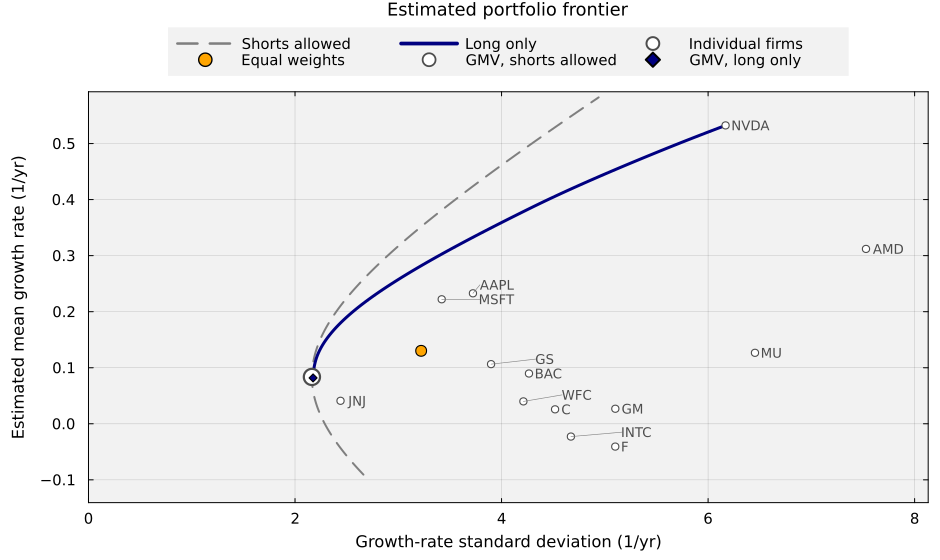

In [15]:
let
    # Compare allocations using the same estimated mean and covariance -
    M = length(my_list_of_tickers); # number of firms
    σ_single = sqrt.(diag(Σ̂_g)); # individual growth-rate standard deviations (1/yr)
    w_eq = (1/M)*ones(M); # equal portfolio weights
    label_y = copy(ĝ); # initial label heights (1/yr)
    label_order = sortperm(ĝ); # place labels from low to high mean growth
    label_gap_x = 0.06*maximum(σ_single); # horizontal range for nearby labels (1/yr)
    label_gap_y = 0.045*(maximum(ĝ) - minimum(ĝ)); # vertical label separation (1/yr)
    label_offset_x = 0.009*maximum(σ_single); # distance from each point to its label (1/yr)
    label_x = σ_single .+ label_offset_x; # initial label positions (1/yr)

    # Separate nearby labels without moving the portfolio points -
    for i ∈ 1:M, j ∈ 1:M
        if abs(σ_single[i] - σ_single[j]) < label_gap_x && abs(ĝ[i] - ĝ[j]) < label_gap_y
            label_x[i] = max(label_x[i], σ_single[j] + label_offset_x);
        end
    end
    # Raise labels only when they overlap earlier labels; do not alter the plotted growth estimates.
    for (k, i) ∈ enumerate(label_order)
        for j ∈ label_order[1:k-1]
            if abs(label_x[i] - label_x[j]) < label_gap_x
                label_y[i] = max(label_y[i], label_y[j] + label_gap_y);
            end
        end
    end

    # Plot frontier coordinates as (standard deviation, mean growth), both in year⁻¹.
    plot(hyperbola_df.σ, hyperbola_df.g, ls = :dash, lw = 2, c = :gray50, label = "Shorts allowed")
    plot!(frontier_df.σ, frontier_df.g, lw = 3, c = :navy, label = "Long only")
    scatter!(σ_single, ĝ, ms = 4, c = :white, msc = :gray30, label = "Individual firms")
    # Connect displaced labels back to the actual single-asset points.
    for i ∈ 1:M
        if label_y[i] != ĝ[i] || label_x[i] != σ_single[i] + label_offset_x
            plot!([σ_single[i], label_x[i]], [ĝ[i], label_y[i]],
                c = :gray50, lw = 0.6, label = false)
        end
        annotate!(label_x[i], label_y[i], text(my_list_of_tickers[i], 9, :left, :gray30))
    end
    scatter!([sqrt(w_eq'*Σ̂_g*w_eq)], [ĝ'*w_eq], ms = 6, c = :orange, label = "Equal weights")
    scatter!([σ_GMV_closed], [ĝ'*w_GMV_closed], ms = 9, c = :white, msc = :gray30,
        msw = 2, marker = :circle, label = "GMV, shorts allowed")
    scatter!([sqrt(w_GMV'*Σ̂_g*w_GMV)], [ĝ'*w_GMV], ms = 4, c = :navy,
        marker = :diamond, label = "GMV, long only")
    plot!(xlabel = "Growth-rate standard deviation (1/yr)", ylabel = "Estimated mean growth rate (1/yr)",
        xlim = (0.0, 1.08*maximum(σ_single)),
        ylim = (min(minimum(ĝ), minimum(hyperbola_df.g)) - 0.05, maximum(label_y) + 0.06),
        title = "Estimated portfolio frontier", titlefontsize = 12, guidefontsize = 11, tickfontsize = 10,
        bg = "gray95", background_color_outside = "white", framestyle = :box,
        fg_legend = :transparent, legend = :outertop, legend_column = 3, legendfontsize = 10,
        size = (940, 560), left_margin = 5Plots.mm, bottom_margin = 4Plots.mm)
end

Moving up means more estimated mean growth; moving left means less risk. Compare the individual firms and equal-weight portfolio with the blue frontier. Where the blue curve lies to the right of the dashed curve, excluding short positions requires more risk to achieve the same mean growth.

### Track the allocations
The portfolio weights change along the long-only frontier. Let's display them as stacked color bands using [the `areaplot(...)` function](https://docs.juliaplots.org/stable/api/#Plots.areaplot-Tuple):

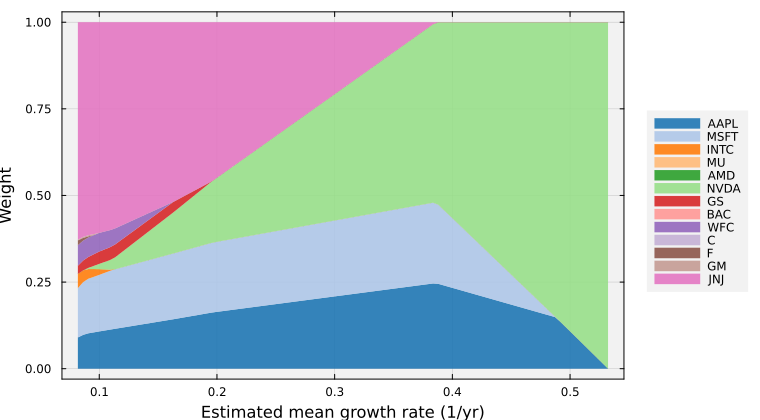

In [16]:
let
    # Stack weight vectors as columns, then transpose to the layout required by areaplot -
    W = hcat(frontier_df.w...)'; # rows are frontier points, columns are firms
    # Each band is one firm; nonnegative weights sum to one at every solved frontier point.
    areaplot(frontier_df.g, W, labels = permutedims(my_list_of_tickers), lw = 0, alpha = 0.9, palette = :tab20,
        xlabel = "Estimated mean growth rate (1/yr)", ylabel = "Weight", legend = :outerright,
        bg = "gray95", background_color_outside = "white", framestyle = :box, fg_legend = :transparent, size = (760, 420))
end

Each colored band's thickness gives one firm's weight. The table compares the GMV portfolio, a point near the middle of the sweep, and the last solved target:

In [17]:
let
    # Compare rows of the successfully solved sweep, not indices in the original target grid.
    k_mid = round(Int, nrow(frontier_df)/2); # row near the middle of the solved sweep
    k_end = nrow(frontier_df); # row for the last solved target
    df = DataFrame(ticker = my_list_of_tickers, w_GMV = round.(frontier_df.w[1], digits=4) .+ 0.0, 
        w_mid = round.(frontier_df.w[k_mid], digits=4) .+ 0.0,
        w_high = round.(frontier_df.w[k_end], digits=4) .+ 0.0);
    pretty_table(df, backend = :text, table_format = TextTableFormat(borders = text_table_borders__compact))
    # The first target is GMV when solved successfully; report achieved growth and risk for each row.
    for (name, k) ∈ [("GMV", 1), ("mid", k_mid), ("high", k_end)]
        println("$(name): E[g] = $(round(frontier_df.g[k], digits=4)) 1/yr, σ = $(round(frontier_df.σ[k], digits=4)) 1/yr")
    end
end

 -------- --------- --------- ---------
  ticker     w_GMV     w_mid    w_high 
  String   Float64   Float64   Float64 
 -------- --------- --------- ---------
    AAPL    0.0902    0.2098    0.0003
    MSFT    0.1423    0.2196       0.0
    INTC     0.041       0.0       0.0
      MU       0.0       0.0       0.0
     AMD       0.0       0.0       0.0
    NVDA       0.0    0.3694    0.9997
      GS    0.0236       0.0       0.0
     BAC       0.0       0.0       0.0
     WFC    0.0595       0.0       0.0
       C       0.0       0.0       0.0
       F    0.0137       0.0       0.0
      GM     0.002       0.0       0.0
     JNJ    0.6277    0.2012       0.0
 -------- --------- --------- ---------
GMV: E[g] = 0.0818 1/yr, σ = 2.1749 1/yr
mid: E[g] = 0.3025 1/yr, σ = 3.4184 1/yr
high: E[g] = 0.5323 1/yr, σ = 6.1678 1/yr


Compare the three columns to see how the holdings change as the growth target rises. Near the largest individual mean growth, most weight must go to the firms with the highest estimates.

### Add a risk-free asset
Now add an asset with constant growth rate $g_f$ and zero variance. For a risky portfolio $p$, write its estimated mean growth as $g_p^{\prime}=(\mathbf{g}^{\prime})^{\top}\mathbf{w}$ and its growth-rate standard deviation as $\sigma_{g,p}>0$. Putting a fraction $w_f$ in the risk-free asset and $1-w_f$ in $p$ gives the complete portfolio $c$, with estimated growth statistics:
$$
\begin{aligned}
g_c^{\prime}
&=w_f g_f+(1-w_f)g_p^{\prime}\\
&=g_f+(1-w_f)(g_p^{\prime}-g_f),\\
\sigma_{g,c}&=|1-w_f|\,\sigma_{g,p}.
\end{aligned}
$$
For $w_f\leq1$, we can eliminate $w_f$ to obtain the **capital allocation line (CAL)**:
$$
g_c^{\prime}=g_f+\mathrm{SR}_p\,\sigma_{g,c},
\qquad
\mathrm{SR}_p=\frac{g_p^{\prime}-g_f}{\sigma_{g,p}}.
$$
The line connects the risk-free asset to portfolio $p$. Its slope, the Sharpe ratio $\mathrm{SR}_p$, measures estimated excess growth per unit of growth-rate standard deviation.

### Choose the tangent portfolio
The **tangent portfolio** $\mathcal{T}$ has the largest Sharpe ratio and therefore the steepest CAL. We approximate the long-only tangent portfolio by comparing the Sharpe ratios at the frontier points already computed and selecting the largest using [the `argmax(...)` function](https://docs.julialang.org/en/v1/base/collections/#Base.argmax).

This selects the best portfolio on our sampled grid. We store its row in `k_tan` and its weights in `w_tan`; the assertion checks that its estimated mean growth exceeds the risk-free rate:

In [18]:
# Approximate long-only tangency by maximizing the Sharpe ratio over solved grid points -
k_tan, w_tan = let
    SR = (frontier_df.g .- g_f) ./ frontier_df.σ; # entrywise excess growth / growth-rate std
    k = argmax(SR); # row with the largest estimated Sharpe ratio
    @assert SR[k] > 0 # selected portfolio has positive estimated excess growth
    (k, frontier_df.w[k]); # Return
end;

### Compute tangent weights with short positions
For comparison, allow short positions and define the estimated excess-growth vector $\mathbf{e}=\mathbf{g}^{\prime}-g_f\mathbf{1}$. With a positive-definite covariance matrix and a closed-form GMV portfolio whose estimated mean growth exceeds $g_f$, the lecture gives the tangent weights as:
$$
\mathbf{w}_{\mathcal{T}}
=\frac{\hat{\mathbf{\Sigma}}_g^{-1}\mathbf{e}}
{\mathbf{1}^{\top}\hat{\mathbf{\Sigma}}_g^{-1}\mathbf{e}}.
$$
As in the GMV calculation, we call the numerator $\mathbf{x}$. We compute it by solving $\hat{\mathbf{\Sigma}}_g\mathbf{x}=\mathbf{e}$, then divide by the sum of its entries to obtain weights that sum to one. The denominator is positive under the growth condition above; the assertion checks this before we store the weights in `w_tan_closed`:

In [19]:
# Solve the shorts-allowed tangent formula using excess mean growth -
# Positive sum(x) is required for the normalized solution to maximize, rather than minimize, Sharpe.
w_tan_closed = let
    M = length(my_list_of_tickers); # number of firms
    e = ĝ .- g_f*ones(M); # estimated excess growth rates (1/yr)
    x = Σ̂_g \ e; # numerator of the tangent formula: weights before normalization
    @assert sum(x) > 0 # positive normalization gives the maximum-Sharpe portfolio
    x / sum(x); # normalize the weights to sum to one
end;

### Compare the tangent portfolios
Our Sharpe ratio uses the standard deviation of a one-day growth rate, so it describes one trading interval. Under the L5a assumption of independent increments and constant growth parameters, we annualize to a horizon of $\tau=1$ year using:
$$
\mathrm{SR}_p^{\mathrm{annual}}
=\sqrt{\frac{\tau}{\Delta t}}\,\mathrm{SR}_p
=\frac{\sqrt{\tau}\,(g_p^{\prime}-g_f)}
{\sqrt{\mathbf{w}^{\top}\hat{\mathbf{C}}\mathbf{w}}},
\qquad
\hat{\mathbf{C}}=\Delta t\,\hat{\mathbf{\Sigma}}_g.
$$
For $\Delta t=1/252$ years, the multiplier is $\sqrt{252}\approx15.9$. This common multiplier leaves the portfolio ranking unchanged. Below, we compare the weights, estimated mean growth, standard deviation, and both Sharpe ratios:

In [20]:
let
    # Compare risky-fund weights in the common asset order; these exclude the risk-free allocation -
    df = DataFrame(
        ticker = my_list_of_tickers,
        w_tan_long_only = round.(w_tan, digits=4) .+ 0.0,
        w_tan_closed_form = round.(w_tan_closed, digits=4)
    );
    # Report sums of full-precision weights; negative entries are short positions.
    push!(df, (
        ticker = "sum",
        w_tan_long_only = round(sum(w_tan), digits=4),
        w_tan_closed_form = round(sum(w_tan_closed), digits=4)
    ));
    pretty_table(df, backend = :text,
        table_format = TextTableFormat(borders = text_table_borders__compact))
end

 -------- ----------------- -------------------
  ticker   w_tan_long_only   w_tan_closed_form
  String           Float64             Float64
 -------- ----------------- -------------------
    AAPL            0.2013              0.9105
    MSFT            0.1254              0.8981
    INTC               0.0             -1.2905
      MU               0.0             -0.3306
     AMD               0.0             -0.0969
    NVDA            0.6733              1.7119
      GS               0.0              0.8209
     BAC               0.0              1.3224
     WFC               0.0             -0.1146
       C               0.0             -1.5773
       F               0.0             -0.9966
      GM               0.0              0.0965
     JNJ               0.0             -0.3537
     sum               1.0                 1.0
 -------- ----------------- -------------------


The closed-form portfolio uses short positions to fund additional long holdings, while the weights still sum to one. A weight above one means that a single holding exceeds the initial budget. Next, compare the estimated growth, standard deviation, and Sharpe ratios for these allocations:

In [ ]:
let
    # Compare both Sharpe conventions without changing the portfolio weights -
    df = DataFrame(
        "Portfolio" => String[],
        "Mean growth (1/yr)" => Float64[],
        "σ_g (1/yr)" => Float64[],
        "SR (one day)" => Float64[],
        "Annualized SR" => Float64[]
    );
    τ = 1.0; # annualization horizon (yr)
    for (name, w) ∈ [("Long only", w_tan), ("Closed form", w_tan_closed)]
        g = ĝ'*w; # estimated portfolio mean growth (1/yr)
        σ = sqrt(w'*Σ̂_g*w); # growth-rate standard deviation (1/yr)
        SR = (g - g_f)/σ; # one-day Sharpe ratio
        # Square-root-time scaling assumes independent increments and constant model parameters.
        SR_annual = sqrt(τ/Δt)*SR; # annualized Sharpe ratio
        push!(df, (name, round(g, digits=4), round(σ, digits=4),
            round(SR, digits=4), round(SR_annual, digits=3)));
    end
    pretty_table(df, backend = :text,
        table_format = TextTableFormat(borders = text_table_borders__compact))
end

 ------------- -------------------- ------------ -------------- ---------------
    Portfolio   Mean growth (1/yr)   σ_g (1/yr)   SR (one day)   Annualized SR
       String              Float64      Float64        Float64         Float64
 ------------- -------------------- ------------ -------------- ---------------
    Long only               0.4332       4.8455         0.0809           1.285
  Closed form               1.4695      12.5284          0.114            1.81
 ------------- -------------------- ------------ -------------- ---------------


Here, allowing short positions produces a higher estimated Sharpe ratio and a higher standard deviation than the long-only portfolio on the training data.

Let's draw the CAL through the long-only tangent portfolio on top of the frontier. `Unhide` the code block below to see how:

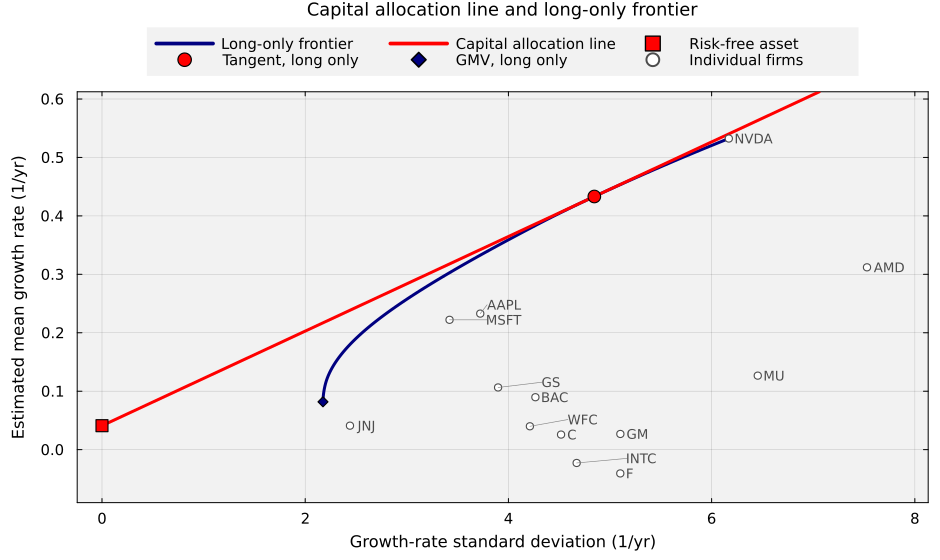

In [21]:
let
    # Draw the line through the risk-free point and the sampled long-only tangent candidate -
    M = length(my_list_of_tickers); # number of firms
    σ_single = sqrt.(diag(Σ̂_g)); # individual growth-rate standard deviations (1/yr)
    σ_tan = frontier_df.σ[k_tan]; # tangent growth-rate standard deviation (1/yr)
    g_tan = frontier_df.g[k_tan]; # tangent estimated mean growth (1/yr)
    SR_tan = (g_tan - g_f)/σ_tan; # slope of the tangent portfolio's CAL
    σ_max = 1.08*maximum(σ_single); # right plot limit (1/yr)
    label_y = copy(ĝ); # initial label heights (1/yr)
    label_order = sortperm(ĝ); # place labels from low to high mean growth
    label_gap_x = 0.06*maximum(σ_single); # horizontal range for nearby labels (1/yr)
    label_gap_y = 0.045*(maximum(ĝ) - minimum(ĝ)); # vertical label separation (1/yr)
    label_offset_x = 0.009*maximum(σ_single); # distance from each point to its label (1/yr)
    label_x = σ_single .+ label_offset_x; # initial label positions (1/yr)

    # Separate nearby labels without moving the portfolio points -
    for i ∈ 1:M, j ∈ 1:M
        if abs(σ_single[i] - σ_single[j]) < label_gap_x && abs(ĝ[i] - ĝ[j]) < label_gap_y
            label_x[i] = max(label_x[i], σ_single[j] + label_offset_x);
        end
    end
    # Adjust annotation positions only; retain all portfolio coordinates.
    for (k, i) ∈ enumerate(label_order)
        for j ∈ label_order[1:k-1]
            if abs(label_x[i] - label_x[j]) < label_gap_x
                label_y[i] = max(label_y[i], label_y[j] + label_gap_y);
            end
        end
    end

    plot(frontier_df.σ, frontier_df.g, lw = 3, c = :navy, label = "Long-only frontier")
    # The two endpoints define g = g_f + SR_tan σ; extending beyond tangency represents borrowing.
    plot!([0.0, σ_max], [g_f, g_f + SR_tan*σ_max],
        lw = 3, c = :red, label = "Capital allocation line")
    scatter!([0.0], [g_f], ms = 6, c = :red, marker = :square, label = "Risk-free asset")
    scatter!([σ_tan], [g_tan], ms = 7, c = :red, label = "Tangent, long only")
    scatter!([frontier_df.σ[1]], [frontier_df.g[1]], ms = 5, c = :navy,
        marker = :diamond, label = "GMV, long only")
    scatter!(σ_single, ĝ, ms = 4, c = :white, msc = :gray30, label = "Individual firms")
    for i ∈ 1:M
        if label_y[i] != ĝ[i] || label_x[i] != σ_single[i] + label_offset_x
            plot!([σ_single[i], label_x[i]], [ĝ[i], label_y[i]],
                c = :gray50, lw = 0.6, label = false)
        end
        annotate!(label_x[i], label_y[i], text(my_list_of_tickers[i], 9, :left, :gray30))
    end
    plot!(xlabel = "Growth-rate standard deviation (1/yr)", ylabel = "Estimated mean growth rate (1/yr)",
        xlim = (-0.03*σ_max, σ_max),
        ylim = (min(0.0, minimum(ĝ), g_f) - 0.05, max(maximum(label_y), g_f) + 0.08),
        title = "Capital allocation line and long-only frontier",
        titlefontsize = 12, guidefontsize = 11, tickfontsize = 10,
        bg = "gray95", background_color_outside = "white", framestyle = :box,
        fg_legend = :transparent, legend = :outertop, legend_column = 3, legendfontsize = 10,
        size = (940, 560), left_margin = 5Plots.mm, bottom_margin = 4Plots.mm)
end

Between the risk-free asset and $\mathcal{T}$, we lend part of the budget at $g_f$ ($0<w_f<1$). Beyond $\mathcal{T}$, we borrow at $g_f$ to invest more than the initial budget in the risky portfolio ($w_f<0$). This is **two-fund separation**: the risky fund stays the same while $w_f$ sets the risk level.

An exact tangent CAL touches the long-only frontier and offers at least as much estimated growth at the same standard deviation; our sampled tangent portfolio approximates this result. The CAL compares the linear growth statistic $\mathbf{w}^{\top}\mathbf{g}$; next, we evaluate the weights using actual buy-and-hold price ratios in 2025.

___

## Task 3: How Did the Portfolios Do Out of Sample?
We now test the long-only GMV and tangent portfolios on 2025 data, using the weights estimated from 2014–2024 as their initial allocations. We compare their buy-and-hold wealth with an initially equal-weight portfolio and the [SPY ETF](https://en.wikipedia.org/wiki/SPDR_S%26P_500), a proxy for the S&P 500 index. All four start with the same initial wealth $W_0$ on the first testing day.

### Build the testing-price matrix
The matrix `prices_2025` contains the 2025 volume-weighted average prices $S_i(t)$. Each row is a trading day, and the columns follow the order in `my_list_of_tickers`:

In [22]:
prices_2025 = let
    N = nrow(dataset_2025["AAPL"]); # number of trading days in the testing data
    M = length(my_list_of_tickers); # number of selected firms
    # Allocate uninitialized storage, then fill every column before returning it.
    S = Array{Float64,2}(undef, N, M); # prices: trading days × firms
    for (i, ticker) ∈ enumerate(my_list_of_tickers)
        S[:,i] = dataset_2025[ticker][:, :volume_weighted_average_price]; # aligned dates; USD/share
    end
    S; # Return
end;

### Compute buy-and-hold wealth
For initial portfolio weights $w_i$ and initial wealth $W_0$, the L5a buy-and-hold rule gives:
$$
W_t=W_0\sum_{i=1}^{M}w_i\frac{S_i(t)}{S_i(0)}.
$$
Here, $S_i(0)$ is firm $i$'s price on the first testing day, and $S_i(t)$ is its price at time $t$. **Buy-and-hold fixes the number of shares**, so portfolio weights can change as prices move.

**Why no discounting?** $W_t$ is the dollar value of our holdings at time $t$. For a sale at that time, the NPV relative to the risk-free alternative is:
$$
\operatorname{NPV}(g_f,t)
=\underbrace{e^{-g_f t}W_t}_{\text{discounted sale proceeds}}
-\underbrace{W_0}_{\text{initial investment}}.
$$
Here, $t$ is measured in years. Discounting expresses the proceeds in time-zero dollars; subtracting $W_0$ measures the gain over the risk-free alternative. At a common date and discount rate, this preserves the ranking of the four portfolios.

Each wealth path has one entry per trading day. We store the four paths in `wealth_2025`, a dictionary keyed by portfolio name:

In [23]:
wealth_2025 = let
    M = length(my_list_of_tickers); # number of selected firms
    # Transpose the initial-price vector to broadcast each firm's denominator down its column.
    price_ratio = prices_2025 ./ prices_2025[1,:]'; # S_i(t)/S_i(0), one column per firm
    wealth = Dict{String, Array{Float64,1}}(); # wealth paths keyed by portfolio name
    for (name, w) ∈ [
        ("GMV (long only)", w_GMV),
        ("tangent (long only)", w_tan),
        ("equal weights", (1/M)*ones(M))
    ]
        wealth[name] = W₀*(price_ratio*w); # sum fixed-share holding values at each date, in USD
    end
    # Price-ratio weighting uses initial fractions; it does not rebalance the holdings each day.
    spy = dataset_2025["SPY"][:, :volume_weighted_average_price]; # daily SPY prices
    wealth["SPY"] = W₀*(spy ./ spy[1]); # SPY wealth from the same initial investment
    wealth; # Return
end;

### Compare the wealth paths
Let's plot the four scaled wealth paths, $W_t/W_0$, over the 2025 trading days. Each path starts at one; a value above one indicates an increase in dollar wealth. `Unhide` the code block below to see how:

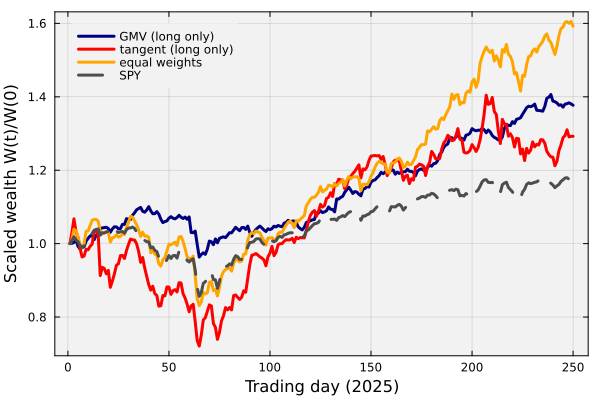

In [24]:
let
    # Compare normalized wealth; the implicit horizontal coordinate is the price-row index -
    p = plot();
    for (name, c, ls) ∈ [
        ("GMV (long only)", :navy, :solid),
        ("tangent (long only)", :red, :solid),
        ("equal weights", :orange, :solid),
        ("SPY", :gray30, :dash)
    ]
        # Divide dollar wealth by the common initial budget; this is not discounted NPV.
        plot!(wealth_2025[name] ./ W₀, lw = 3, c = c, ls = ls, label = name)
    end
    plot!(xlabel = "Trading day (2025)", ylabel = "Scaled wealth W(t)/W(0)",
        bg = "gray95", background_color_outside = "white", framestyle = :box,
        fg_legend = :transparent, legend = :topleft)
end

### Compare realized growth and risk
The paths show both ending wealth and fluctuations along the way. To compare these features numerically, the table reports:

- **Final wealth ratio:** $W_T/W_0$.
- **Realized mean growth:** $\ln(W_T/W_0)/T$, in inverse years.
- **Growth-rate standard deviation:** the sample standard deviation of the daily rates $\ln(W_{t_k}/W_{t_{k-1}})/\Delta t$, also in inverse years.

Here, $t_k$ is the $k$th trading time, and $T$ is the number of observed trading intervals multiplied by $\Delta t$. We compute daily log changes with [the `diff(...)` function](https://docs.julialang.org/en/v1/base/arrays/#Base.diff):

In [25]:
let
    # Measure realized buy-and-hold growth from wealth changes, not from the weighted-growth proxy -
    df = DataFrame(
        portfolio = String[],
        W_T_over_W_0 = Float64[],
        growth_2025 = Float64[],
        σ_g_2025 = Float64[]
    );
    for name ∈ ["GMV (long only)", "tangent (long only)", "equal weights", "SPY"]
        W = wealth_2025[name]; # buy-and-hold wealth path
        T = (length(W) - 1)*Δt; # elapsed testing period (yr)
        # Differences of log wealth equal log wealth ratios; positive wealth is required.
        g_daily = diff(log.(W)) ./ Δt; # realized daily growth rates (1/yr)
        # The mean interval rate telescopes to log(W_T/W_0)/T; std uses the sample correction.
        push!(df, (
            portfolio = name,
            W_T_over_W_0 = round(W[end]/W[1], digits=4),
            growth_2025 = round(log(W[end]/W[1])/T, digits=4),
            σ_g_2025 = round(std(g_daily), digits=3)
        ));
    end
    pretty_table(df, backend = :text,
        table_format = TextTableFormat(borders = text_table_borders__compact))
end

 --------------------- -------------- ------------- ----------
            portfolio   W_T_over_W_0   growth_2025   σ_g_2025 
               String        Float64       Float64    Float64 
 --------------------- -------------- ------------- ----------
      GMV (long only)          1.377        0.3238      1.996
  tangent (long only)         1.2924        0.2596      5.113
        equal weights         1.5921        0.4706      3.487
                  SPY         1.1691        0.1581      2.206
 --------------------- -------------- ------------- ----------


For the displayed selection, GMV has the lowest realized growth-rate standard deviation, while equal weights produce the largest year-end wealth. The tangent portfolio grows less than GMV in 2025, despite its higher estimated mean growth in the training data.

This is one test year. To assess persistence, we would repeat the comparison across periods, using only earlier data to estimate each allocation.

___

## Summary
In this example, we estimated mean growth rates and covariances from historical data and used them to solve portfolio optimization problems for the allocation weights. We then evaluated those allocations on a separate year of prices.

> __Key Takeaways:__
>
> * **Estimated inputs and minimum variance:** We estimated mean growth rates and covariances from the training data, then computed GMV portfolios with and without short positions. Long-only bounds removed some allocation choices, so the minimum standard deviation could stay the same or increase.
>
> * **The frontier and capital allocation line:** We swept growth targets to trace the long-only efficient frontier and selected the sampled portfolio with the highest Sharpe ratio. Adding the risk-free asset gave a CAL through that portfolio, showing how lending or borrowing changes risk while retaining the same risky allocation.
>
> * **Buy-and-hold performance:** We applied the initial allocations to 2025 prices and compared wealth, realized growth, and growth-rate standard deviation. For the displayed selection, GMV had the lowest realized risk, while equal weights ended with the most wealth. More test periods are needed to assess persistence.

In L6a, we introduce the single-index model to describe how asset growth rates vary together using fewer parameters.

___

## Disclaimer and Risks
__This content is offered solely for training and informational purposes__. No offer or solicitation to buy or sell securities or derivative products or any investment or trading advice or strategy is made, given, or endorsed by the teaching team. 

__Trading involves risk__. Carefully review your financial situation before investing in securities, futures contracts, options, or commodity interests. Past performance, whether actual or indicated by historical tests of strategies, is no guarantee of future performance or success. Trading is generally inappropriate for someone with limited resources, investment or trading experience, or a low-risk tolerance. Only risk capital that is not required for living expenses should be used.

__You are fully responsible for any investment or trading decisions you make__. Such decisions should be based solely on evaluating your financial circumstances, investment or trading objectives, risk tolerance, and liquidity needs.
